# WAP 모델 코드 재현

- 참고사항: WAP모델 읽어보면, 수식 특성 상 작은 local 부분의 관계를 놓치지 않기 위해 imagenet을 통해 학습한 대부분의 모델이 초반 7x7의 stem layer를 가지는 반면 WAP모델은 3x3 conv만으로 구성됨 (수식 이미지 도메인의 특성을 고려했다고 생각하면 될듯)
- 같은 맥락에서, 인코더 구조도 densenet 방식처럼 사용했지만 실제 densenet을 그대로 사용하지 않고, 직접 densenet 비슷한 구조를 구현한 것임 (Densenet-like)

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

In [46]:
model.state_dict().keys()

odict_keys(['embed.weight', 'encoder.backbone.0.weight', 'encoder.backbone.1.weight', 'encoder.backbone.1.bias', 'encoder.backbone.1.running_mean', 'encoder.backbone.1.running_var', 'encoder.backbone.1.num_batches_tracked', 'encoder.backbone.4.denselayer1.norm1.weight', 'encoder.backbone.4.denselayer1.norm1.bias', 'encoder.backbone.4.denselayer1.norm1.running_mean', 'encoder.backbone.4.denselayer1.norm1.running_var', 'encoder.backbone.4.denselayer1.norm1.num_batches_tracked', 'encoder.backbone.4.denselayer1.conv1.weight', 'encoder.backbone.4.denselayer1.norm2.weight', 'encoder.backbone.4.denselayer1.norm2.bias', 'encoder.backbone.4.denselayer1.norm2.running_mean', 'encoder.backbone.4.denselayer1.norm2.running_var', 'encoder.backbone.4.denselayer1.norm2.num_batches_tracked', 'encoder.backbone.4.denselayer1.conv2.weight', 'encoder.backbone.4.denselayer2.norm1.weight', 'encoder.backbone.4.denselayer2.norm1.bias', 'encoder.backbone.4.denselayer2.norm1.running_mean', 'encoder.backbone.4.den

In [47]:
len(model.state_dict().keys())

733

In [51]:
model.state_dict()['encoder.backbone.0.weight'].shape

torch.Size([64, 1, 7, 7])

In [53]:
data['dense_b0_l0'].shape

(24, 96, 3, 3)

In [ ]:
def load_npz_to_torch(model, npz_path):
    data = np.load(npz_path, allow_pickle=Ture)
    state_dict = model.state_dict()

    mapping = {}
    for key in data.files:
        arr = data[key]
        arr = arr.squeeze()

        if "bn_mean" in key:
            torch_key = key.replace("dense_b", "features.denseblock").replace("_l", "denselayer").replace("_bn_mean", ".norm1.running_mean")

In [48]:
len(data.files)

330

In [56]:
import pickle

with open('attention_maxlen[200]_dimWord256_dim256.npz.pkl', "rb") as f:
    data = pickle.load(f)

data

{'stride_conv1': [2, 2],
 'channel_conv1': 48,
 'lrate': 1e-08,
 'decay_c': 0.0001,
 'patience': 15,
 'clip_c': 100.0,
 'max_epochs': 5000,
 'dispFreq': 100,
 'GrowthRate': 24,
 'batch_Imagesize': 400000,
 'input_channels': 1,
 'bn_saveto': './models/bn_params.npz',
 'maxlen': 200,
 'DenseBlock': [16, 16, 16],
 'saveto': './models/attention_maxlen[200]_dimWord256_dim256.npz',
 'dim_coverage': 512,
 'valid_result': ['./result/valid.wer'],
 'valid_batch_size': 8,
 'maxImagesize': 400000,
 'Bottleneck': True,
 'dim_dec': 256,
 'validFreq': -1,
 'kernel_coverage': [11, 11],
 'optimizer': 'adadelta',
 'alpha_c': 0.0,
 'Transition': 0.5,
 'valid_output': ['./result/valid_decode_result.txt'],
 'batch_size': 8,
 'encoder': 'gru',
 'dim_target': 111,
 'decoder': 'gru_cond',
 'valid_datasets': ['../data/offline-test.pkl', '../data/test_caption.txt'],
 'use_dropout': True,
 'datasets': ['../data/offline-train.pkl', '../data/train_caption.txt'],
 'dim_word': 256,
 'sampleFreq': -1,
 'dim_attention

In [59]:
import numpy as np

data = np.load('attention_maxlen[200]_dimWord256_dim256.npz')
# data = np.load('bn_params.npz')



for key in data.files:
    try:
        arr = data[key]
        print(key, arr.shape, arr.dtype)

    except:
        print(f"skipped: {key}")


ff_logit_W (128, 111) float32
dense_b2_l7_bn_gamma (1, 24, 1, 1) float32
dense_b2_l14_bn_beta (1, 24, 1, 1) float32
dense_b2_l3_bn_beta (1, 24, 1, 1) float32
dense_b2_l11_bn_beta (1, 24, 1, 1) float32
dense_input_bn_gamma (1, 48, 1, 1) float32
dense_B_b0_l8_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l11 (96, 564, 1, 1) float32
dense_B_b2_l10 (96, 540, 1, 1) float32
dense_B_b2_l13 (96, 612, 1, 1) float32
dense_B_b2_l12 (96, 588, 1, 1) float32
dense_B_b2_l15 (96, 660, 1, 1) float32
dense_B_b2_l14 (96, 636, 1, 1) float32
dense_B_b1_l7_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l4_bn_beta (1, 96, 1, 1) float32
dense_b1_l15 (24, 96, 3, 3) float32
dense_B_b1_l13_bn_gamma (1, 96, 1, 1) float32
dense_b1_l14 (24, 96, 3, 3) float32
dense_b2_l2_bn_gamma (1, 24, 1, 1) float32
dense_B_b1_l7_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l13_bn_beta (1, 96, 1, 1) float32
dense_b2_l13_bn_gamma (1, 24, 1, 1) float32
dense_B_b0_l0 (96, 48, 1, 1) float32
dense_b0_l4_bn_beta (1, 24, 1, 1) float32
dense_b1_l5_bn_g

In [ ]:
ff_logit_W (128, 111) float32

dense_b1_l15 (24, 96, 3, 3) float32
dense_b1_l14 (24, 96, 3, 3) float32
dense_b2_l2_bn_gamma (1, 24, 1, 1) float32
dense_b2_l3_bn_beta (1, 24, 1, 1) float32
dense_b2_l7_bn_gamma (1, 24, 1, 1) float32
dense_b2_l11_bn_beta (1, 24, 1, 1) float32
dense_b2_l14_bn_beta (1, 24, 1, 1) float32

dense_input_bn_gamma (1, 48, 1, 1) float32


dense_B_b0_l8_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l13_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l7_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l11 (96, 564, 1, 1) float32
dense_B_b2_l10 (96, 540, 1, 1) float32
dense_B_b2_l13_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l13 (96, 612, 1, 1) float32
dense_b2_l13_bn_gamma (1, 24, 1, 1) float32
dense_B_b2_l12 (96, 588, 1, 1) float32
dense_B_b2_l15 (96, 660, 1, 1) float32
dense_B_b2_l14 (96, 636, 1, 1) float32
dense_B_b1_l7_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l4_bn_beta (1, 96, 1, 1) float32

dense_B_b0_l0 (96, 48, 1, 1) float32

dense_b0_l4_bn_beta (1, 24, 1, 1) float32
dense_b1_l5_bn_gamma (1, 24, 1, 1) float32
dense_b1_l10_bn_beta (1, 24, 1, 1) float32
decoder_Wc (684, 512) float32

dense_B_b2_l5_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l0_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l6_bn_gamma (1, 96, 1, 1) float32

dense_b0_l12_bn_beta (1, 24, 1, 1) float32
dense_b2_l11_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l3_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l14_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l15_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l11_bn_beta (1, 96, 1, 1) float32

ff_logit_b (111,) float32

dense_B_b1_l10_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l13_bn_gamma (1, 96, 1, 1) float32

decoder_Wcx (684, 256) float32

dense_B_b1_l14_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l12_bn_beta (1, 96, 1, 1) float32

decoder_Wx (256, 256) float32
dense_b1_l3_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l3_bn_beta (1, 96, 1, 1) float32

Wemb_dec (111, 256) float32

dense_B_b0_l4_bn_beta (1, 96, 1, 1) float32

dense_b2_l9_bn_gamma (1, 24, 1, 1) float32
dense_b0_l0_bn_gamma (1, 24, 1, 1) float32
dense_b1_l14_bn_gamma (1, 24, 1, 1) float32
dense_b1_l1_bn_beta (1, 24, 1, 1) float32

dense_B_b0_l9_bn_gamma (1, 96, 1, 1) float32

dense_C_b1_bn_beta (1, 300, 1, 1) float32

dense_b2_l15_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l10_bn_beta (1, 96, 1, 1) float32

dense_b0_l8 (24, 96, 3, 3) float32
dense_b0_l9 (24, 96, 3, 3) float32
dense_b0_l6 (24, 96, 3, 3) float32
dense_b0_l7 (24, 96, 3, 3) float32
dense_b0_l4 (24, 96, 3, 3) float32
dense_b0_l5 (24, 96, 3, 3) float32
dense_b0_l2 (24, 96, 3, 3) float32
dense_b0_l3 (24, 96, 3, 3) float32
dense_b0_l0 (24, 96, 3, 3) float32
dense_b0_l1 (24, 96, 3, 3) float32

dense_B_b0_l13 (96, 360, 1, 1) float32
dense_B_b0_l12 (96, 336, 1, 1) float32
dense_B_b0_l11 (96, 312, 1, 1) float32

dense_b0_l11_bn_gamma (1, 24, 1, 1) float32
dense_b0_l13_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l15 (96, 408, 1, 1) float32
dense_B_b0_l14 (96, 384, 1, 1) float32

decoder_Ux_nl (256, 256) float32
dense_b1_l11_bn_gamma (1, 24, 1, 1) float32
dense_b2_l6_bn_gamma (1, 24, 1, 1) float32
decoder_conv_b (512,) float32
dense_b1_l0_bn_gamma (1, 24, 1, 1) float32
dense_b0_l13_bn_beta (1, 24, 1, 1) float32
dense_b2_l8 (24, 96, 3, 3) float32

dense_B_b2_l14_bn_beta (1, 96, 1, 1) float32

dense_b2_l13 (24, 96, 3, 3) float32
dense_b2_l0 (24, 96, 3, 3) float32
dense_b2_l1 (24, 96, 3, 3) float32
dense_b2_l2 (24, 96, 3, 3) float32
decoder_bx (256,) float32
dense_b2_l4 (24, 96, 3, 3) float32

dense_B_b1_l11_bn_gamma (1, 96, 1, 1) float32

dense_b2_l6 (24, 96, 3, 3) float32
dense_b2_l7 (24, 96, 3, 3) float32
dense_b1_l1 (24, 96, 3, 3) float32

dense_B_b0_l8_bn_gamma (1, 96, 1, 1) float32

dense_b1_l3 (24, 96, 3, 3) float32
dense_b1_l2 (24, 96, 3, 3) float32
dense_b1_l5 (24, 96, 3, 3) float32
dense_b1_l4 (24, 96, 3, 3) float32
dense_b1_l7 (24, 96, 3, 3) float32
dense_b1_l6 (24, 96, 3, 3) float32
dense_b1_l9 (24, 96, 3, 3) float32
dense_b1_l8 (24, 96, 3, 3) float32

dense_B_b0_l2_bn_gamma (1, 96, 1, 1) float32
dense_B_b0_l14_bn_beta (1, 96, 1, 1) float32

decoder_U (256, 512) float32

dense_B_b0_l5_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l15 (96, 576, 1, 1) float32

dense_b2_l1_bn_beta (1, 24, 1, 1) float32
ff_state_b (256,) float32
dense_b2_l13_bn_beta (1, 24, 1, 1) float32
dense_b1_l1_bn_gamma (1, 24, 1, 1) float32
ff_logit_prev_W (256, 256) float32
dense_b1_l10 (24, 96, 3, 3) float32
dense_b0_l15 (24, 96, 3, 3) float32

dense_B_b2_l11_bn_gamma (1, 96, 1, 1) float32

ff_state_W (684, 256) float32

dense_B_b0_l4_bn_gamma (1, 96, 1, 1) float32

decoder_b (512,) float32
dense_b2_l9 (24, 96, 3, 3) float32
ff_logit_prev_b (256,) float32

dense_B_b1_l9 (96, 432, 1, 1) float32

decoder_bx_nl (256,) float32
dense_b2_l14_bn_gamma (1, 24, 1, 1) float32

dense_B_b2_l0_bn_beta (1, 96, 1, 1) float32

dense_b0_l8_bn_gamma (1, 24, 1, 1) float32

dense_B_b2_l9_bn_beta (1, 96, 1, 1) float32
dense_B_b0_l1_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l8_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l7_bn_beta (1, 96, 1, 1) float32

dense_b1_l13 (24, 96, 3, 3) float32
dense_b0_l5_bn_gamma (1, 24, 1, 1) float32
dense_b2_l10 (24, 96, 3, 3) float32
decoder_conv_Uf (512, 512) float32

dense_B_b1_l4_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l14 (96, 552, 1, 1) float32

dense_b1_l12_bn_beta (1, 24, 1, 1) float32

dense_B_b1_l12 (96, 504, 1, 1) float32
dense_B_b1_l13 (96, 528, 1, 1) float32
dense_B_b1_l10 (96, 456, 1, 1) float32
dense_B_b1_l11 (96, 480, 1, 1) float32
dense_B_b0_l13_bn_beta (1, 96, 1, 1) float32

dense_b0_l2_bn_gamma (1, 24, 1, 1) float32
dense_b1_l7_bn_gamma (1, 24, 1, 1) float32

dense_B_b1_l1_bn_beta (1, 96, 1, 1) float32
dense_B_b0_l3 (96, 120, 1, 1) float32
dense_B_b0_l2 (96, 96, 1, 1) float32
dense_B_b0_l1 (96, 72, 1, 1) float32
dense_B_b0_l10_bn_beta (1, 96, 1, 1) float32
dense_B_b0_l7 (96, 216, 1, 1) float32
dense_B_b0_l6 (96, 192, 1, 1) float32
dense_B_b0_l5 (96, 168, 1, 1) float32

decoder_Wc_att (512, 684, 1, 1) float32
dense_b1_l12 (24, 96, 3, 3) float32

dense_B_b0_l8 (96, 240, 1, 1) float32
dense_B_b1_l0_bn_gamma (1, 96, 1, 1) float32

dense_b1_l13_bn_gamma (1, 24, 1, 1) float32
dense_b0_l7_bn_gamma (1, 24, 1, 1) float32
dense_b2_l3 (24, 96, 3, 3) float32
dense_b2_l0_bn_beta (1, 24, 1, 1) float32
dense_b2_l4_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l6_bn_gamma (1, 96, 1, 1) float32

dense_b0_l15_bn_beta (1, 24, 1, 1) float32

dense_B_b1_l10_bn_beta (1, 96, 1, 1) float32

dense_b2_l5 (24, 96, 3, 3) float32

dense_B_b2_l1 (96, 324, 1, 1) float32
dense_B_b2_l0 (96, 300, 1, 1) float32
dense_B_b2_l3 (96, 372, 1, 1) float32
dense_B_b2_l2 (96, 348, 1, 1) float32

dense_b1_l9_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l4 (96, 396, 1, 1) float32

dense_b1_l7_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l6 (96, 444, 1, 1) float32
dense_B_b2_l9 (96, 516, 1, 1) float32
dense_B_b2_l8 (96, 492, 1, 1) float32
dense_B_b2_l10_bn_gamma (1, 96, 1, 1) float32

dense_b1_l11 (24, 96, 3, 3) float32

dense_B_b0_l1_bn_beta (1, 96, 1, 1) float32

dense_b2_l10_bn_gamma (1, 24, 1, 1) float32
dense_b0_l3_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l0_bn_beta (1, 96, 1, 1) float32
dense_B_b0_l10_bn_gamma (1, 96, 1, 1) float32

dense_b0_l9_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l4 (96, 144, 1, 1) float32
dense_B_b0_l12_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l5_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l12_bn_gamma (1, 96, 1, 1) float32

dense_C_b0_bn_beta (1, 216, 1, 1) float32
dense_b2_l10_bn_beta (1, 24, 1, 1) float32

dense_B_b0_l9 (96, 264, 1, 1) float32

ff_logit_ctx_W (684, 256) float32

dense_B_b2_l15_bn_beta (1, 96, 1, 1) float32

dense_b2_l12_bn_gamma (1, 24, 1, 1) float32
dense_b2_l5_bn_gamma (1, 24, 1, 1) float32
dense_b0_l4_bn_gamma (1, 24, 1, 1) float32
dense_b1_l10_bn_gamma (1, 24, 1, 1) float32
dense_b1_l5_bn_beta (1, 24, 1, 1) float32
decoder_b_att (512,) float32

dense_B_b0_l12_bn_gamma (1, 96, 1, 1) float32

dense_b2_l9_bn_beta (1, 24, 1, 1) float32
dense_b0_l10_bn_beta (1, 24, 1, 1) float32
dense_b0_l11_bn_beta (1, 24, 1, 1) float32
dense_B_b2_l7_bn_gamma (1, 96, 1, 1) float32
dense_b0_l14_bn_gamma (1, 24, 1, 1) float32

dense_C_b0 (216, 432, 1, 1) float32

dense_B_b1_l13_bn_beta (1, 96, 1, 1) float32

dense_b0_l10_bn_gamma (1, 24, 1, 1) float32
dense_b2_l15_bn_gamma (1, 24, 1, 1) float32

dense_C_b1 (300, 600, 1, 1) float32

dense_B_b0_l2_bn_beta (1, 96, 1, 1) float32

dense_b2_l2_bn_beta (1, 24, 1, 1) float32
decoder_U_nl (256, 512) float32
dense_b2_l0_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l0_bn_gamma (1, 96, 1, 1) float32

dense_b2_l4_bn_beta (1, 24, 1, 1) float32

dense_B_b0_l7_bn_gamma (1, 96, 1, 1) float32

dense_b0_l9_bn_beta (1, 24, 1, 1) float32
dense_b2_l7_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l1_bn_gamma (1, 96, 1, 1) float32

ff_logit_gru_b (256,) float32
dense_b2_l12_bn_beta (1, 24, 1, 1) float32
dense_b2_l11 (24, 96, 3, 3) float32

dense_B_b0_l15_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l12_bn_gamma (1, 96, 1, 1) float32

dense_b1_l9_bn_gamma (1, 24, 1, 1) float32
decoder_c_tt (1,) float32

dense_B_b0_l11_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l9_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l4_bn_beta (1, 96, 1, 1) float32

dense_b0_l2_bn_beta (1, 24, 1, 1) float32

dense_B_b1_l15_bn_gamma (1, 96, 1, 1) float32

dense_b0_l5_bn_beta (1, 24, 1, 1) float32
dense_b1_l11_bn_beta (1, 24, 1, 1) float32

dense_C_b0_bn_gamma (1, 216, 1, 1) float32

dense_B_b2_l4_bn_gamma (1, 96, 1, 1) float32

decoder_W_comb_att (256, 512) float32
dense_b2_l8_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l2_bn_beta (1, 96, 1, 1) float32

dense_input_bn_beta (1, 48, 1, 1) float32

dense_B_b2_l5_bn_gamma (1, 96, 1, 1) float32

dense_b2_l6_bn_beta (1, 24, 1, 1) float32
dense_b2_l12 (24, 96, 3, 3) float32
decoder_W (256, 512) float32

dense_B_b1_l8_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l3_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l2_bn_gamma (1, 96, 1, 1) float32

dense_b1_l4_bn_gamma (1, 24, 1, 1) float32

dense_B_b1_l2_bn_beta (1, 96, 1, 1) float32

dense_b0_l15_bn_gamma (1, 24, 1, 1) float32
dense_b0_l3_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l8_bn_gamma (1, 96, 1, 1) float32

decoder_b_nl (512,) float32
ff_logit_ctx_b (256,) float32
dense_b2_l15 (24, 96, 3, 3) float32

dense_B_b0_l15_bn_beta (1, 96, 1, 1) float32

dense_input (48, 1, 7, 7) float32

dense_B_b1_l1_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l6_bn_gamma (1, 96, 1, 1) float32
dense_B_b0_l6_bn_beta (1, 96, 1, 1) float32
dense_B_b0_l5_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l5_bn_gamma (1, 96, 1, 1) float32

history_errs (119,) float64

dense_B_b0_l14_bn_gamma (1, 96, 1, 1) float32
dense_B_b2_l3_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l4 (96, 312, 1, 1) float32
dense_B_b1_l5 (96, 336, 1, 1) float32
dense_B_b1_l6 (96, 360, 1, 1) float32
dense_B_b1_l7 (96, 384, 1, 1) float32
dense_B_b1_l0 (96, 216, 1, 1) float32

dense_b1_l8_bn_beta (1, 24, 1, 1) float32

dense_B_b1_l2 (96, 264, 1, 1) float32

dense_b0_l12_bn_gamma (1, 24, 1, 1) float32
dense_b0_l6_bn_gamma (1, 24, 1, 1) float32
dense_b1_l12_bn_gamma (1, 24, 1, 1) float32
dense_b1_l3_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l6_bn_beta (1, 96, 1, 1) float32
dense_B_b1_l8 (96, 408, 1, 1) float32

dense_b1_l13_bn_beta (1, 24, 1, 1) float32

dense_B_b2_l14_bn_gamma (1, 96, 1, 1) float32

dense_b0_l1_bn_beta (1, 24, 1, 1) float32
dense_b1_l15_bn_gamma (1, 24, 1, 1) float32
dense_b1_l2_bn_gamma (1, 24, 1, 1) float32

dense_B_b1_l8_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l5 (96, 420, 1, 1) float32

decoder_Ux (256, 256) float32

dense_B_b0_l7_bn_beta (1, 96, 1, 1) float32

dense_b1_l0_bn_beta (1, 24, 1, 1) float32
dense_b0_l7_bn_beta (1, 24, 1, 1) float32
dense_b0_l10 (24, 96, 3, 3) float32
dense_b0_l11 (24, 96, 3, 3) float32
dense_b0_l12 (24, 96, 3, 3) float32
dense_b0_l13 (24, 96, 3, 3) float32
dense_b0_l14 (24, 96, 3, 3) float32

dense_B_b2_l7 (96, 468, 1, 1) float32

dense_b0_l8_bn_beta (1, 24, 1, 1) float32
dense_b1_l0 (24, 96, 3, 3) float32

dense_B_b2_l15_bn_gamma (1, 96, 1, 1) float32

dense_b1_l6_bn_beta (1, 24, 1, 1) float32

dense_B_b1_l0_bn_beta (1, 96, 1, 1) float32

dense_C_b1_bn_gamma (1, 300, 1, 1) float32

dense_b0_l0_bn_beta (1, 24, 1, 1) float32
dense_b1_l8_bn_gamma (1, 24, 1, 1) float32
skipped: zipped_params

dense_B_b1_l12_bn_beta (1, 96, 1, 1) float32
dense_B_b0_l11_bn_beta (1, 96, 1, 1) float32

dense_b0_l6_bn_beta (1, 24, 1, 1) float32

dense_B_b1_l6_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l3_bn_gamma (1, 96, 1, 1) float32

dense_b1_l6_bn_gamma (1, 24, 1, 1) float32

dense_B_b0_l13_bn_gamma (1, 96, 1, 1) float32
dense_B_b1_l3_bn_beta (1, 96, 1, 1) float32

dense_b2_l3_bn_gamma (1, 24, 1, 1) float32

dense_B_b1_l1 (96, 240, 1, 1) float32
dense_B_b2_l1_bn_beta (1, 96, 1, 1) float32

dense_b0_l1_bn_gamma (1, 24, 1, 1) float32

dense_B_b1_l2_bn_gamma (1, 96, 1, 1) float32

dense_b1_l15_bn_beta (1, 24, 1, 1) float32
dense_b1_l2_bn_beta (1, 24, 1, 1) float32

dense_B_b0_l9_bn_beta (1, 96, 1, 1) float32
dense_B_b2_l9_bn_gamma (1, 96, 1, 1) float32

dense_b1_l4_bn_beta (1, 24, 1, 1) float32
decoder_conv_Q (512, 1, 11, 11) float32

dense_B_b1_l3 (96, 288, 1, 1) float32

dense_b0_l14_bn_beta (1, 24, 1, 1) float32
ff_logit_gru_W (256, 256) float32
dense_b2_l14 (24, 96, 3, 3) float32

dense_B_b1_l11_bn_beta (1, 96, 1, 1) float32

decoder_U_att (512, 1) float32

dense_B_b0_l10 (96, 288, 1, 1) float32
dense_B_b1_l9_bn_beta (1, 96, 1, 1) float32

dense_b1_l14_bn_beta (1, 24, 1, 1) float32
dense_b2_l5_bn_beta (1, 24, 1, 1) float32
dense_b2_l8_bn_gamma (1, 24, 1, 1) float32
dense_b2_l1_bn_gamma (1, 24, 1, 1) float32

In [ ]:
# stem
dense_input (48, 1, 7, 7) float32
dense_input_bn_gamma (1, 48, 1, 1) float32
dense_input_bn_beta (1, 48, 1, 1) float32

# dense block 0
dense_b0_l0 … dense_b0_l15 (24, 96, 3, 3) float32
dense_b0_lX_bn_gamma / bn_beta (1, 24, 1, 1) float32

# transition 0 (bottleneck + compression)
dense_B_b0_l0 … dense_B_b0_l15 (96, *, 1, 1) float32
dense_B_b0_lX_bn_gamma / bn_beta (1, 96, 1, 1) float32
dense_C_b0 (216, 432, 1, 1) float32
dense_C_b0_bn_gamma (1, 216, 1, 1) float32
dense_C_b0_bn_beta (1, 216, 1, 1) float32

# dense block 1
dense_b1_l0 … dense_b1_l15 (24, 96, 3, 3) float32
dense_b1_lX_bn_gamma / bn_beta (1, 24, 1, 1) float32

# transition 1
dense_B_b1_l0 … dense_B_b1_l15 (96, *, 1, 1) float32
dense_B_b1_lX_bn_gamma / bn_beta (1, 96, 1, 1) float32
dense_C_b1 (300, 600, 1, 1) float32
dense_C_b1_bn_gamma (1, 300, 1, 1) float32
dense_C_b1_bn_beta (1, 300, 1, 1) float32

# dense block 2
dense_b2_l0 … dense_b2_l15 (24, 96, 3, 3) float32
dense_b2_lX_bn_gamma / bn_beta (1, 24, 1, 1) float32

# transition 2
dense_B_b2_l0 … dense_B_b2_l15 (96, *, 1, 1) float32
dense_B_b2_lX_bn_gamma / bn_beta (1, 96, 1, 1) float32

# decoder / attention
Wemb_dec (111, 256) float32
decoder_Wc (684, 512) float32
decoder_Wcx (684, 256) float32
decoder_W (256, 512) float32
decoder_Wx (256, 256) float32
decoder_U (256, 512) float32
decoder_Ux (256, 256) float32
decoder_Ux_nl (256, 256) float32
decoder_U_nl (256, 512) float32
decoder_b (512,) float32
decoder_bx (256,) float32
decoder_bx_nl (256,) float32
decoder_b_nl (512,) float32
decoder_c_tt (1,) float32
decoder_conv_Q (512, 1, 11, 11) float32
decoder_conv_Uf (512, 512) float32
decoder_conv_b (512,) float32
decoder_Wc_att (512, 684, 1, 1) float32
decoder_W_comb_att (256, 512) float32
decoder_U_att (512, 1) float32
decoder_b_att (512,) float32

# fully connected
ff_state_W (684, 256) float32
ff_state_b (256,) float32
ff_logit_prev_W (256, 256) float32
ff_logit_prev_b (256,) float32
ff_logit_gru_W (256, 256) float32
ff_logit_gru_b (256,) float32
ff_logit_ctx_W (684, 256) float32
ff_logit_ctx_b (256,) float32
ff_logit_W (128, 111) float32
ff_logit_b (111,) float32

# history
history_errs (119,) float64

In [ ]:
'	33
<eol>	0

In [4]:
a = set(['2',
'p',
'k',
'N',
'-',
'7',
'0',
'1',
'P',
'a',
'9',
'6',
'm',
'H',
'z',
'g',
'v',
'3',
'I',
'd',
's',
'5',
'4',
'8',
'\log',
'|',
'S',
'y',
'>',
'/',
'V',
'.',
'r',
'o',
't',
'x',
'q',
'A',
'+',
'w',
'l',
'<',
'b',
'f',
'[',
']',
'\mu',
'e',
',',
'n',
'B',
'c',
'E',
'(',
'\pi',
')',
'F',
'\{',
'\}',
'\in',
'\geq',
'\neq',
'\div',
'\phi',
'\leq',
'u',
'i',
'\tan',
'M',
'^',
'{',
'}',
'R',
'_',
'=',
'\beta',
'j',
'T',
'L',
'X',
'\theta',
'\times',
'G',
'\int',
'\cos',
'Y',
'\prime',
'\sqrt',
'\sin',
'C',
'\alpha',
'\sum',
'\ldots',
'\pm',
'\sigma',
'\rightarrow',
'\Delta',
'\frac',
'\gamma',
'\Pi',
'\forall',
'\limits',
'\infty',
'\exists',
'\cdot',
'!',
'h',
'\lim',
'\cdots',
'\lambda'])

<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\{'
<>:59: SyntaxWarning: invalid escape sequence '\}'
<>:60: SyntaxWarning: invalid escape sequence '\i'
<>:61: SyntaxWarning: invalid escape sequence '\g'
<>:63: SyntaxWarning: invalid escape sequence '\d'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:84: SyntaxWarning: invalid escape sequence '\i'
<>:85: SyntaxWarning: invalid escape sequence '\c'
<>:87: SyntaxWarning: invalid escape sequence '\p'
<>:88: SyntaxWarning: invalid escape sequence '\s'
<>:89: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:93: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\p'
<>:95: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid e

In [8]:
b = set(['\geq',
'\sqrt',
'\leq',
'/',
'\infty',
'(',
',',
'0',
'\cdot',
'8',
'\sigma',
'<',
'\pm',
'\log',
'\pi',
'H',
'L',
'P',
'\limits',
'T',
'X',
'd',
'h',
'\}',
'l',
'p',
't',
'\tan',
'x',
'|',
'\gamma',
'\{',
"'",
'+',
'\theta',
'\forall',
'3',
'7',
'\int',
'\sin',
'\prime',
'C',
'G',
'\ldots',
'S',
'[',
'_',
'c',
'z',
'\cdots',
'g',
'k',
'o',
's',
'w',
'\cos',
'{',
'\Delta',
'\neq',
'\in',
'\alpha',
'\times',
'\lim',
'.',
'2',
'6',
'\lambda',
'4',
'B',
'F',
'\exists',
'N',
'R',
'V',
'^',
'b',
'f',
'j',
'n',
'r',
'v',
'>',
'\frac',
'\rightarrow',
'\div',
'!',
'\phi',
')',
'-',
'1',
'5',
'9',
'=',
'A',
'E',
'\beta',
'I',
'M',
'Y',
']',
'\mu',
'a',
'e',
'i',
'\sum',
'm',
'q',
'u',
'y',
'}'])

<>:1: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\}'
<>:31: SyntaxWarning: invalid escape sequence '\g'
<>:32: SyntaxWarning: invalid escape sequence '\{'
<>:39: SyntaxWarning: invalid escape sequence '\i'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:58: SyntaxWarning: invalid escape

In [9]:
len(b)

110

In [10]:
a - b

{'\\Pi'}

In [11]:
b - a

{"'"}

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Dense Layer ---
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate, bottleneck=True):
        super().__init__()
        inter_channels = growth_rate * 4 if bottleneck else growth_rate

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, stride=1, bias=False)

        self.bn2 = nn.BatchNorm2d(inter_channels)
        self.conv2 = nn.Conv2d(inter_channels, growth_rate, kernel_size=3, stride=1, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(out)))
        out = torch.cat([x, out], 1)
        return out

# --- Dense Block ---
class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate, n_layers):
        super().__init__()
        layers = []
        channels = in_channels
        for i in range(n_layers):
            layers.append(DenseLayer(channels, growth_rate))
            channels += growth_rate
        self.block = nn.Sequential(*layers)
        self.out_channels = channels

    def forward(self, x):
        return self.block(x)

# --- Transition Layer ---
class Transition(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        out = self.pool(out)
        return out

# --- Encoder (DenseNet-like) ---
class Encoder(nn.Module):
    def __init__(self, growth_rate=24, block_layers=[16,16,16]):
        super().__init__()
        self.conv0 = nn.Conv2d(1, 48, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn0 = nn.BatchNorm2d(48)
        self.relu = nn.ReLU(inplace=True)
        self.pool0 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        channels = 48
        self.blocks = nn.ModuleList()
        self.trans = nn.ModuleList()

        for i, n_layers in enumerate(block_layers):
            block = DenseBlock(channels, growth_rate, n_layers)
            self.blocks.append(block)
            channels = block.out_channels
            if i != len(block_layers)-1:
                self.trans.append(Transition(channels, channels // 2))
                channels = channels // 2
        self.out_channels = channels

    def forward(self, x):
        out = self.pool0(self.relu(self.bn0(self.conv0(x))))
        for i, block in enumerate(self.blocks):
            out = block(out)
            if i < len(self.trans):
                out = self.trans[i](out)
        return out  # (B, C, H, W)

# --- Attention Decoder ---
class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=256, enc_dim=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim + enc_dim, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim + enc_dim, 1)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, enc_feats, tgt_seq):
        # enc_feats: (B, C, H, W)
        B, C, H, W = enc_feats.shape
        enc_seq = enc_feats.flatten(2).permute(0,2,1)  # (B, L, C)

        hidden = torch.zeros(1, B, self.gru.hidden_size, device=enc_feats.device)
        outputs = []
        for t in range(tgt_seq.size(1)):
            emb = self.embedding(tgt_seq[:,t])  # (B, emb_dim)

            # Attention
            hidden_expand = hidden[-1].unsqueeze(1).expand(-1, enc_seq.size(1), -1)
            attn_weights = torch.tanh(torch.cat([enc_seq, hidden_expand], dim=-1))
            attn_weights = self.attn(attn_weights).squeeze(-1)
            alpha = F.softmax(attn_weights, dim=1)
            context = torch.bmm(alpha.unsqueeze(1), enc_seq).squeeze(1)

            # GRU step
            gru_input = torch.cat([emb, context], dim=-1).unsqueeze(1)
            out, hidden = self.gru(gru_input, hidden)

            out_vocab = self.fc_out(out.squeeze(1))
            outputs.append(out_vocab)
        return torch.stack(outputs, dim=1)  # (B, T, V)

# --- Full Model ---
class DenseAttnModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = AttentionDecoder(vocab_size)

    def forward(self, x, tgt_seq):
        enc_out = self.encoder(x)
        dec_out = self.decoder(enc_out, tgt_seq)
        return dec_out


# Utils

- 필요에 따라 추후 WER도 계산하는거 구현해서 metric으로 사용해도 좋을듯

In [21]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 2

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='auto', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [22]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=2):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]

In [23]:
import os
import json

def save_log(log_dict, save_path="log.json"):
    """학습 로그를 JSON으로 저장."""
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"로그 저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):
    """Loss 곡선 시각화."""

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3"], "metric은 loss, expr@0, expr@2, expr@3 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric.upper()} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric.upper()} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [24]:
import gspread

def save_test_result(experiment_name, test_dataset_name, val, metric="loss"):
    """ 실험결과를 구글스프레드시트에 저장 """

    assert test_dataset_name in ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX*"], \
        "테스트데이터셋 이름은 CROHME_2014, CROHME_2016, CROHME_2019, CROPME_2014, CROPME_2016, CROPME_2019, IM2LATEX* 중 하나여야 합니다"

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3"], "metric은 loss, expr@0, expr@2, expr@3 중 선택하여 입력해야합니다"

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")
    worksheet = sh.worksheet(metric)

    # experiment_name이 스프레드시트에 존재하는지 확인
    try:
        row = worksheet.find(experiment_name).row
    except:
        last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
        worksheet.update_cell(last_row+1, 1, experiment_name)
        row = last_row + 1

    col = worksheet.find(test_dataset_name).col

    worksheet.update_cell(row, col, val)

# Config (Global Parameters)

In [26]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [143]:
import os, json
from datetime import datetime
import torch

CFG = {
  "experiment_name": "WAP Reproduction",
  "img_size": (128,768)
}

In [28]:
# 실험환경 폴더 생성
from pathlib import Path

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset
- 변경사항: loader 부분에, 첫 에포크 때 학습 느리고 두번째 에포크부터 빨라지는 점 해결하기 위해 num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2 인자 추가

## Vocab

In [137]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  PAD_TOKEN = "<pad>"
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.PAD_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [138]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [139]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [144]:
years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/img_cropped"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption.txt"

In [142]:
# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - IM2LATEX* (vocab 통일한 IM2LATEX의 caption 중 HME pair가 없던 것만 추출해서 test 데이터셋으로 만들어줌, 그러나 40개로, 매우 적은 개수밖에 없으므로 *표시하여 구분하였음)
im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# MODEL

## Encoder

In [40]:
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights


class DenseNetEncoder(nn.Module):

    def __init__(self):
        super().__init__()
        densenet = densenet121(weights=None)    # 이번 프로젝트는 imageNet 데이터에 비교하면 수식글씨로, imageNet 가중치가 방해될 수도 있어 사전학습 가중치 없이 불러오는게 유리할수도 있음

        # First conv layer 수정: in_channels=1로 (우리 프로젝트에 맞춰 gpu 메모리 소모 줄이기 위해 그레이스케일로 변환)
        densenet.features.conv0 = nn.Conv2d(
            in_channels=1, out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        # Remove classification head
        features = list(densenet.features.children())

        # Use all layers except final norm+relu+avgpool
        self.backbone = nn.Sequential(*features[:-1])

        # 가중치 초기화
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.backbone(x)                       # (B,1,128,768) -> (B,1024,4,24)
        B, D, _, _ = x.shape
        x = x.reshape(B, D, -1)                    # (B,1024,4*24)
        x = x.transpose(1,2)                       # (B,1024,96) -> (B,96,1024)
        return x


## Decoder

- 일단 단순성 편의상 num_layers는 nn.GRU에서 자동으로 반영하게 하였음, 그러나 이 경우 context 반영은 가장 초기 hidden cell에 대해서만 가능하고, 레이어별로 context 반영하는 등은 부족
- 만약 RNN 구조로 여러 층에서 context 반영하려면 nn.GRU 대신 nn.GRUCell 이용해서 수정하거나 nn.GRU에 (B,1,H) 대신 각 레이어 별 정보를 담아 (B,L,H)로 넘겨주면 되는듯. 그런데 그럴바에 차라리 셀프 어텐션으로 context 반영하게끔 하는 트랜스포머 구조로 만들어버리는게 나을수도?

In [41]:
import torch
import torch.nn as nn

class Decoder(nn.Module):

    def __init__(self, vocab_size, emb_dim_enc=1024, hidden_dim=256, emb_dim_dec=1024, num_layers=1):
        super().__init__()

        self.gru = nn.GRU(emb_dim_enc+emb_dim_dec, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)


        # weight initialization

        # nn.GRU
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, prev_token, hidden, context):

        # prev_token: (B,D_dec)
        # hidden: (B,H)
        # context: (B,D_enc)

        # 지금은 num_layers는 무조건 1이라서 context는 (B,L,H) 대신 (B,1,H), hidden은 (D*L,B,H) 대신 (D,B,H)로 받는다고 생각하고 unsqueeze 등 shape 변경

        prev_token = prev_token.unsqueeze(1)                  # (B,D_dec) -> (B,1,D_dec)
        context = context.unsqueeze(1)                        # (B,D_enc) -> (B,1,D_enc)

        dec_input = torch.cat([prev_token, context], dim=-1)  # (B,1,D_dec+D_enc)

        # nn.GRU에서 요구하는 hidden 형상 (D*L,B,H)가 되도록 변경
        hidden = hidden.unsqueeze(0)

        output, hidden = self.gru(dec_input, hidden)
        output = output.squeeze(1)                       # (B,1,H) -> (B,H)
        hidden = hidden.squeeze(0)                       # (1,B,H) -> (B,H)

        output_logits = self.fc_out(output)             # (B,H) -> (B,V)
        return output_logits, hidden


## Cross Attention

### 변경사항
- 바다나우 어텐션 시 nn.Linear에서 bias=True, False 부분 조절
- 모델에 inference 함수 추가 => 기존에 하던대로 forward로 예측결과 시각화하면 이때에도 teacher forcing 적용되어버려 제대로된 inference 불가능
    - inference하더라도 예측이 {{{{ 혹은 ''만 나옴 => 원인분석 필요

In [42]:
# paired한 학습이 아니라 단일 도메인에 대해 돌렸을때 성능 나오는지 확인하기 위해 Paired 없을때 단일도메인 내 인코더-디코더 간 어텐션만 추가해서 구성한 Lite 모델

import torch.nn.functional as F
import random

class DLAModel_Lite(nn.Module):
    def __init__(self, model_config=None):
        super().__init__()

        # 설정 파라미터 추출
        self.vocab_size = model_config.get("vocab_size", 113)
        self.enc_emb_dim = model_config.get("encoder_emb_dim", 256)
        self.dec_emb_dim = model_config.get("decoder_emb_dim", 256)
        self.dec_hid_dim = model_config.get("decoder_hidden_dim", 512)

        self.embed = nn.Embedding(self.vocab_size, self.dec_emb_dim)

        # 인코더
        self.encoder = DenseNetEncoder()
        self.encoder_proj = nn.Linear(1024, self.enc_emb_dim)

        # 바다나우 어텐션 위한 파라미터
        self.W_enc = nn.Linear(self.enc_emb_dim, self.dec_hid_dim, bias=False)
        self.W_hidden = nn.Linear(self.dec_hid_dim, self.dec_hid_dim, bias=True)
        self.v = nn.Linear(self.dec_hid_dim, 1, bias=False)

        # 디코더
        self.decoder = Decoder(self.vocab_size, self.enc_emb_dim, self.dec_hid_dim, self.dec_emb_dim)


        # weight initialization

        # 임베딩 레이어
        nn.init.uniform_(self.embed.weight, -0.1, 0.1)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)


    def forward(self, images, labels, tf_ratio=CFG["training"]["tf_ratio"]):

        # images: (B,1,128,768)
        # labels: (B,T)

        enc = self.encoder(images)     # (B,96,1024)
        enc = self.encoder_proj(enc)   # (B,96,1024) -> (B,96,D_enc)

        B = enc.shape[0]               # batch size

        T = labels.shape[1]            # max_seq_len => <sos>, <eos> 포함

        # PME 디코딩
        dec_out = []

        # <sos>
        prev_token = labels[:, 0]             # (B,) - <sos>
        prev_token = self.embed(prev_token)   # (B,) -> (B,D_dec)

        prev_hidden = torch.zeros((B, self.dec_hid_dim), device=images.device)     # (B,H)


        for t in range(1,T):

            scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)
            scores = self.v(scores).squeeze(2)        # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff = F.softmax(scores, dim=-1)   # (B,96)

            context = enc.transpose(1,2) @ attn_coeff.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context = context.squeeze(2)               # (B,D_enc,1) -> (B,D_enc)

            logits_y, cur_hidden = self.decoder(prev_token, prev_hidden, context)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out.append(logits_y)

            # teacher forcing 적용하는 경우
            if random.random() < tf_ratio:
                prev_token = labels[:, t]             # (B,)

            else:
                prev_token = logits_y.argmax(dim=-1)  # (B,V) -> (B,)

            prev_token = self.embed(prev_token)       # (B,) -> (B,D_dec)
            prev_hidden = cur_hidden


        dec_out = torch.stack(dec_out)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out = dec_out.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        return dec_out


    def inference(self, images, max_seq_len):

        # images: (B,1,128,768)

        enc = self.encoder(images)     # (B,96,D_enc)
        enc = self.encoder_proj(enc)   # (B,96,1024) -> (B,96,D_enc)

        B = enc.shape[0]               # batch size

        # PME 디코딩
        dec_out = []

        # <sos>
        prev_token = torch.ones(B, dtype=torch.long, device=images.device)         # (B,) - <sos>
        prev_token = self.embed(prev_token)                                        # (B,) -> (B,D_dec)

        prev_hidden = torch.zeros((B, self.dec_hid_dim), device=images.device)     # (B,H)


        for t in range(1,max_seq_len):

            scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)
            scores = self.v(scores).squeeze(2)        # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff = F.softmax(scores, dim=-1)   # (B,96)

            context = enc.transpose(1,2) @ attn_coeff.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context = context.squeeze(2)               # (B,D_enc,1) -> (B,D_enc) == (B,D_enc)

            logits_y, cur_hidden = self.decoder(prev_token, prev_hidden, context)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out.append(logits_y)

            # inference 시점이므로 teacher forcing 적용하지 않음
            prev_token = logits_y.argmax(dim=-1)  # (B,V) -> (B,)

            prev_token = self.embed(prev_token)       # (B,) -> (B,D_dec)
            prev_hidden = cur_hidden


        dec_out = torch.stack(dec_out)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out = dec_out.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        return dec_out

# Train

In [ ]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])


    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        num_batches = 0

        loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels)              # (B,T-1,V)
            labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

            optimizer.zero_grad()
            loss.backward()

            if GRAD_CLIP and GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            with torch.no_grad():
                expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)

            total_loss += float(loss.item())
            total_expr_0 += float(expr_0)
            total_expr_1 += float(expr_1)
            total_expr_2 += float(expr_2)
            total_expr_3 += float(expr_3)
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, lr=optimizer.param_groups[0]['lr'])

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches


        print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
              f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}")

        log_dict["Train"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
        })

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(avg_loss)
            else:
                scheduler.step()

        torch.save({"model": model.state_dict()}, save_last)

        if epoch == 1 or avg_loss < best_loss:
            best_loss = avg_loss
            patience = 0
            save_best.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict()}, save_best)
            print("Best model saved.")

        else:
            patience += 1
            if patience >= CFG["training"]["early_stop_patience"]:
                print(f"Early stopping at epoch {epoch}")
                break


        # validation
        model.eval()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        num_batches = 0

        loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels)              # (B,T-1,V)
            labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

            expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
            expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
            expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
            expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))

            total_loss += float(loss.item())
            total_expr_0 += expr_0
            total_expr_1 += expr_1
            total_expr_2 += expr_2
            total_expr_3 += expr_3
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3)

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches


        print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
              f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}")

        log_dict["Valid"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
        })

        print()

    return log_dict, best_loss

In [ ]:
# CosineAnnealingWarmupRestart 커스텀 클래스

import math
from torch.optim.lr_scheduler import _LRScheduler

class CosineAnnealingWarmupRestarts(_LRScheduler):

    def __init__(self,
                 optimizer: torch.optim.Optimizer,
                 first_cycle_steps: int,
                 cycle_mult: float = 1.,
                 max_lr: float = 0.1,
                 min_lr: float = 0.0001,
                 warmup_steps: int = 0,
                 gamma: float = 1.,
                 last_epoch: int = -1):
        assert warmup_steps < first_cycle_steps

        super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

        self.first_cycle_steps = first_cycle_steps
        self.cycle_mult = cycle_mult
        self.base_max_lr = max_lr
        self.min_lr = min_lr
        self.warmup_steps = warmup_steps
        self.gamma = gamma

        self.cur_cycle_steps = first_cycle_steps
        self.cycle = 0
        self.step_in_cycle = last_epoch

        self.init_lr()

    def init_lr(self):
        self.base_lrs = []
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.min_lr
            self.base_lrs.append(self.min_lr)

    def get_lr(self):
        if self.step_in_cycle == -1:
            return self.base_lrs
        elif self.step_in_cycle < self.warmup_steps:
            return [(self.max_lr - base_lr) * self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
        else:
            return [base_lr + (self.max_lr - base_lr) \
                    * (1 + math.cos(math.pi * (self.step_in_cycle - self.warmup_steps) / (self.cur_cycle_steps - self.warmup_steps))) / 2
                    for base_lr in self.base_lrs]

    def step(self, epoch=None):
        if epoch is None:
            epoch = self.last_epoch + 1
            self.step_in_cycle = self.step_in_cycle + 1
            if self.step_in_cycle >= self.cur_cycle_steps:
                self.cycle += 1
                self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
                self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps

        else:
            if epoch >= self.first_cycle_steps:
                if self.cycle_mult == 1.:
                    self.step_in_cycle = epoch % self.first_cycle_steps
                    self.cycle = epoch // self.first_cycle_steps
                else:
                    n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
                    self.cycle = n
                    self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
                    self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)

            else:
                self.cur_cycle_steps = self.first_cycle_steps
                self.step_in_cycle = epoch

        self.max_lr = self.base_max_lr * (self.gamma ** self.cycle)
        self.last_epoch = math.floor(epoch)
        for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
            param_group['lr'] = lr

In [ ]:
import os, json, random
from pathlib import Path
from datetime import datetime

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Vocab
vocab = Vocab()
vocab.load_from_txt(Path(CFG["data"]["vocab"]))
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = DLAModel_Lite(model_config=CFG["model"]).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
params = model.parameters()
if opt_name == "adam":
    optimizer = torch.optim.Adam(params, lr=CFG["training"]["learning_rate"])
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"])
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


# Learning rate 스케쥴러

#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = CosineAnnealingWarmupRestarts(optimizer,
                 first_cycle_steps=200,
                 cycle_mult=1.,
                 max_lr=0.1,
                 min_lr=0.0001,
                 warmup_steps=0,
                 gamma=1.,
                 last_epoch=-1)



# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/50: 100%|██████████| 111/111 [1:25:39<00:00, 46.30s/it, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.37]



[Train Epoch 1] Loss: 4.6047, Expr@0: 0.0000, Expr@1: 0.0000, Expr@2: 0.0000, Expr@3: 0.0000
Best model saved.


[Valid] Epoch 1/50: 100%|██████████| 1767/1767 [22:47<00:00,  1.29it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.71]



[Valid Epoch 1] Loss: 4.4818, Expr@0: 0.0000, Expr@1: 0.0006, Expr@2: 0.0521, Expr@3: 0.0911



[Train] Epoch 2/50: 100%|██████████| 111/111 [01:56<00:00,  1.05s/it, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.11]


...


[Train Epoch 36] Loss: 3.4837, Expr@0: 0.0000, Expr@1: 0.0548, Expr@2: 0.0839, Expr@3: 0.1305


[Valid] Epoch 36/50: 100%|██████████| 1767/1767 [01:17<00:00, 22.67it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.13]



[Valid Epoch 36] Loss: 3.6142, Expr@0: 0.0000, Expr@1: 0.0504, Expr@2: 0.0866, Expr@3: 0.1319



[Train] Epoch 37/50: 100%|██████████| 111/111 [01:56<00:00,  1.05s/it, expr0=0, expr1=0.037, expr2=0.037, expr3=0.111, loss=3.6]


[Train Epoch 37] Loss: 3.4843, Expr@0: 0.0000, Expr@1: 0.0544, Expr@2: 0.0827, Expr@3: 0.1298
Early stopping at epoch 37


In [ ]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

로그 저장 완료: runs/dla_single_epoch50_bs64_lr0.001_schedStepLR2_0.5_patience_2 (revised)/train_log.json


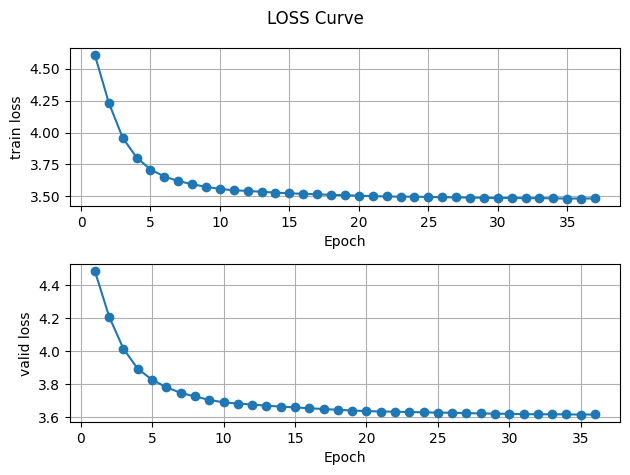

In [ ]:
# 결과 시각화

with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

plot_loss_curve(loss_history, metric="loss", overlap=False)

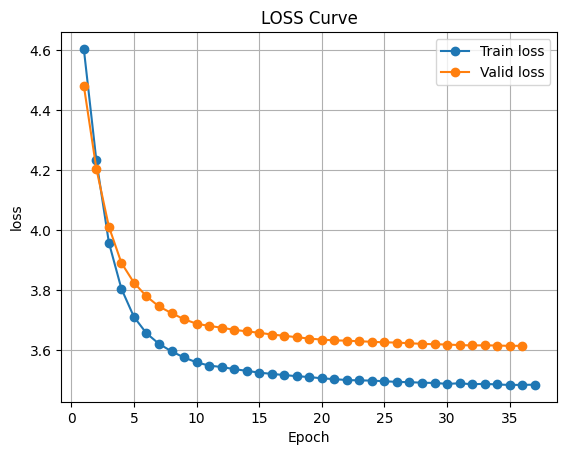

In [ ]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

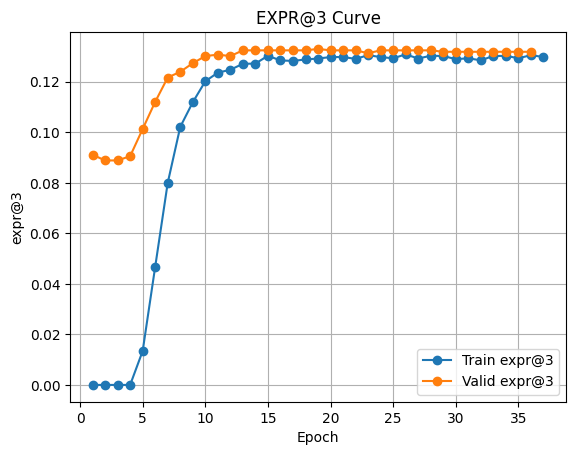

In [ ]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred = model(imgs, labels)              # (B,T-1,V)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))

        total_loss += float(loss.item())
        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3)

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3

In [43]:
# best_model.pth 가져오기

model = DLAModel_Lite(model_config=CFG["model"]).to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [ ]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX*"]

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3 = test(model, test_loader, criterion)

    save_test_result(CFG["paths"]["experiment_name"], test_dataset_name, loss, metric="loss")
    save_test_result(CFG["paths"]["experiment_name"], test_dataset_name, expr0, metric="expr@0")
    save_test_result(CFG["paths"]["experiment_name"], test_dataset_name, expr1, metric="expr@1")
    save_test_result(CFG["paths"]["experiment_name"], test_dataset_name, expr2, metric="expr@2")
    save_test_result(CFG["paths"]["experiment_name"], test_dataset_name, expr3, metric="expr@3")

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [14:21<00:00,  1.14it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2.93]


CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [16:45<00:00,  1.14it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.71]


CROHME_2019


...

[Test] batch:1146/1147: 100%|██████████| 1147/1147 [15:05<00:00,  1.27it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.09]


CROPME_2019


[Test] batch:1198/1199: 100%|██████████| 1199/1199 [16:28<00:00,  1.21it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.13]


IM2LATEX*


  0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
[Test] batch:39/40: 100%|██████████| 40/40 [00:33<00:00,  1.21it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.71]


# Prediction 샘플 시각화
- 모델이 {{{{{ 혹은 ''로 대부분 예측하는 것을 확인할 수 있음 -> collapse가 일어나므로 학습률 문제로 판단, 학습률을 cosineAnnealingRestarts 스케쥴러 이용해서 조절하도록 변경해서 실험할 것.
    - 혹시 모르니, 일단 에포크 중간 부분에서 저장되는 last.pth도 다운로드 해두었다가 나중에 불러와서 예측 어떤식으로 하는지, 이때에도 collapse 일어나는지 확인해보기.
    - 그래도 안된다면 다음으로는 reduceonplateau 스케쥴러 적용해보기

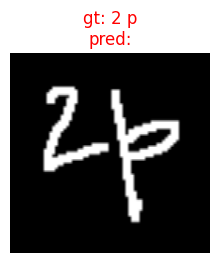

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
display(labels)
display(y_hats)

tensor([[1, 3, 4, 2]], device='cuda:0')

tensor([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2]], device='cuda:0')

In [ ]:
vocab.decode([2, 73, 0, 0, 3, 4])

'<eos> { <pad> <pad> 2 p'

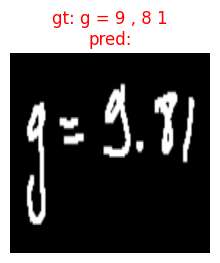

In [ ]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
display(labels)
display(y_hats)

tensor([[  1,  18,  77,  ...,   0,   0,   0],
        [  1,  56,  10,  ...,   0,   0,   0],
        [  1,  35,  77,  ...,   0,   0,   0],
        ...,
        [  1,  56,  30,  ...,   0,   0,   0],
        [  1, 100,  73,  ...,   0,   0,   0],
        [  1,  86, 104,  ...,   0,   0,   0]], device='cuda:0')

tensor([[ 2,  2,  2,  ...,  2,  2,  2],
        [41, 73, 73,  ..., 74, 74, 74],
        [ 2,  2,  2,  ..., 74, 74, 74],
        ...,
        [ 2,  2,  2,  ...,  2,  2,  2],
        [73, 73, 73,  ..., 74, 74, 74],
        [73, 73, 73,  ..., 74, 74, 74]], device='cuda:0')

In [ ]:
y_hats.unique()

tensor([ 2, 41, 73, 74], device='cuda:0')

In [ ]:
vocab.decode([41])

'+'

In [ ]:
(y_hats == 41).sum(axis=-1)

tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

In [ ]:
y_hats[1]

tensor([41, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73,
        73, 73, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74], device='cuda:0')

In [ ]:
vocab.decode(y_hats[1])

'+ { { { { { { { { { { { { { { { { { { { } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } } }'

## 디버깅

- 왜 {{{{ 혹은 '' 만 예측이 될까... exprate가 0이 아닌 값으로 나온 경우는 어떻게 예측한거일지 확인
- exprate 계산 시, 단순히 @k로 해버리면 우연히 토큰길이가 k보다 작으면 아예 예측을 이상하게 해도 맞다고 처리해버리는 문제 발견 => 이 부분 개선하도록 메트릭 수정 및 캐글이나 네이버부스트코스  자료 등 코드에는 이 부분 처리하도록 되어있는지 확인할 것
- 논문에서처럼 학습의 어떤 부분이 이미지의 어떤 부분을 참고하고 있는지 시각화해서 xAI방법에서 디버깅해보기 -> 잘 학습되고 있는지,,, (WAP 논문 시각화를 직접 해보는 느낌)
- 128*768로 resize해서 시작 안하고 128x128에서부터 시작해보기? (지푸라기라도 잡는 심정)
- 어떻게 추가할지는 모르겠지만,정칙화 텀을 추가해보기?
- learning rate 1e-4, patience=4, epoch=100, batch=16으로 다시해보고, WAP 논문 하이퍼파라미터 경우에도 한번 다시해보기 + warmup 및 weight decay도 적용
    - 그래도 안되면 기본 방법은 어느정도 예측 잘할때까지 학습하려면 기본적으로 에포크 너무많이 필요해서 그런거라고 생각하고 트랜스포머 기반으로 바로 적용 시도하는걸로 넘어가기, 트랜스포머 기반으로 두 도메인 이용할 수 있도록 고민해보기)
    - dla나 wap에서 어텐션 이외에 추가적으로 도입했던, 내가 구현할때 미처 반영하지 못한 부분 있으면 반영해서 다시 수정해보기

In [ ]:
y_hats.shape

torch.Size([64, 149])

In [ ]:
ans = []

for i in range(64):
    if exprate_k(y_hats[i].unsqueeze(0), labels[i, 1:-1].unsqueeze(0), k=3, eos_idx=2) != 0:
        ans.append(i)

ans

[7, 23, 25, 26, 38, 45, 58]

In [ ]:
i = 61

In [ ]:
y_hats[i]

tensor([73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73,
        73, 73, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74,
        74, 74, 74, 74, 74], device='cuda:0')

In [ ]:
labels[i, 1:-1]

tensor([10,  9, 38, 72, 73,  3, 74, 90, 73, 24, 41,  3, 90, 73, 24, 74, 74, 41,
        24, 38,  7, 90, 73, 24, 41,  3, 90, 73, 24, 74, 74,  2,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0], device='cuda:0')

In [ ]:
a = y_hats[i].tolist()[:y_hats[i].tolist().index(2)]
vocab.decode(a)

ValueError: 2 is not in list

In [ ]:
b = labels[i, 1:-1].tolist()[:labels[i, 1:-1].tolist().index(2)]
vocab.decode(b)

In [ ]:
a

In [ ]:
b

In [ ]:
editdistance.eval(a,b)

# Next Step
- beamsearch, top-k, top-p 등 다른 디코딩 (inference) 방법 적용
- 구글 스프레드시트에 같은 이름의 실험 반복할 경우 중간에 멈췄을떄 이전 실험 결과로그와 현재 로그가 섞여서 부정확한 데이터 남기는 것 방지위해 일단 한번 해당 실험 결과 업데이트 하는 경우 해당 이름의 결과부분 한번 다 지워두고 채우는 식으로 변경하기
- IM2LATEX warning 해결 (UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn()